# Random Forest Fraud Classification

This notebook is part of the ordered PaySim fraud-detection workflow. See the project README for data setup, evaluation context, and limitations.

## 1. Imports


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 42


# 2. Load processed data

We load X_train, X_test, y_train and y_test from ../data/processed.


In [ ]:
DATA_DIR = Path('../data/processed')

X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').values.ravel()
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').values.ravel()

print("Data loaded successfully.")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


# 3. Logistic Regression baseline

We train the shared baseline model.


In [3]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = y_pred

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_scores),
        "PR-AUC": average_precision_score(y_test, y_scores)
    }

    print(f"\n{model_name} Classification Report")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

    return results



Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       1.00      0.93      0.97     70651
           1       0.01      0.74      0.03        92

    accuracy                           0.93     70743
   macro avg       0.51      0.84      0.50     70743
weighted avg       1.00      0.93      0.96     70743



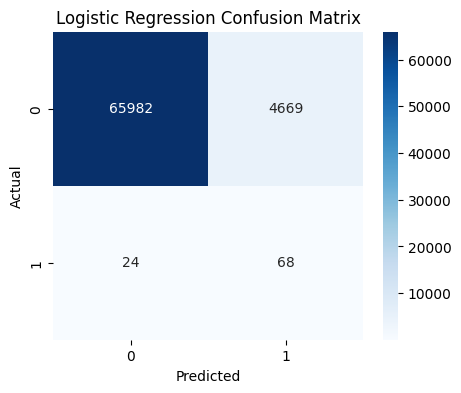

In [4]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

log_reg.fit(X_train, y_train)

log_reg_results = evaluate_model(
    "Logistic Regression",
    log_reg,
    X_test,
    y_test
)

# 4. Main model

Now we train the assigned model.



Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70651
           1       1.00      0.91      0.95        92

    accuracy                           1.00     70743
   macro avg       1.00      0.96      0.98     70743
weighted avg       1.00      1.00      1.00     70743



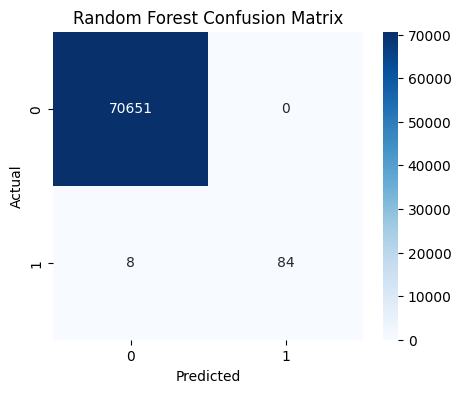

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    "Random Forest",
    rf_model,
    X_test,
    y_test
)

## 5. Decision Threshold

The threshold below is an exploratory operating point evaluated on the test set. It must be selected on validation data before these threshold-dependent metrics can be treated as an unbiased final estimate.


# 6. Model evaluation

We plot ROC and PR curves.


<Figure size 700x500 with 0 Axes>

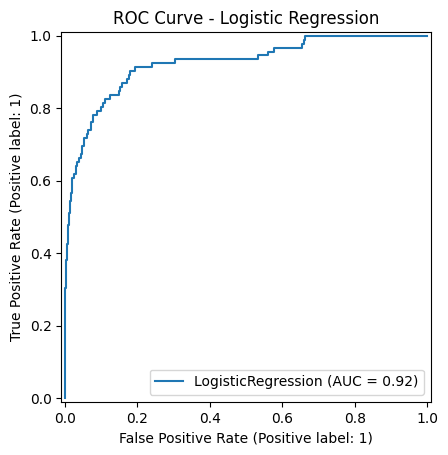

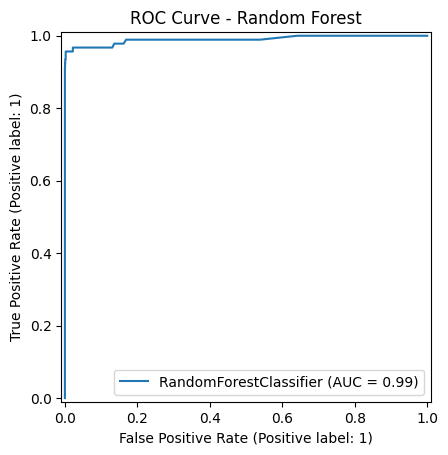

In [8]:
plt.figure(figsize=(7, 5))

RocCurveDisplay.from_estimator(log_reg, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

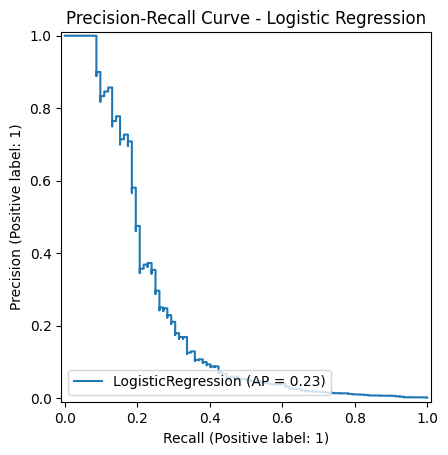

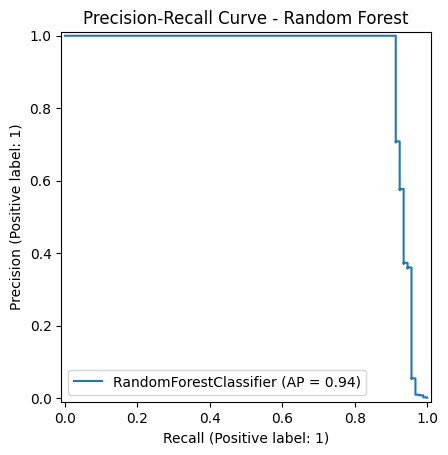

In [9]:
PrecisionRecallDisplay.from_estimator(log_reg, X_test, y_test)
plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

PrecisionRecallDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Precision-Recall Curve - Random Forest")
plt.show()

# 7. Feature importance or model interpretation

Random Forest gives feature importance.


In [10]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
6,sender_balance_error,0.332235
10,amount_to_balance_ratio,0.269350
3,newbalanceOrig,0.090525
8,sender_balance_change,0.074791
4,oldbalanceDest,0.058425
5,newbalanceDest,0.052924
2,oldbalanceOrg,0.039185
9,receiver_balance_change,0.025602
1,amount,0.022821
7,receiver_balance_error,0.018250


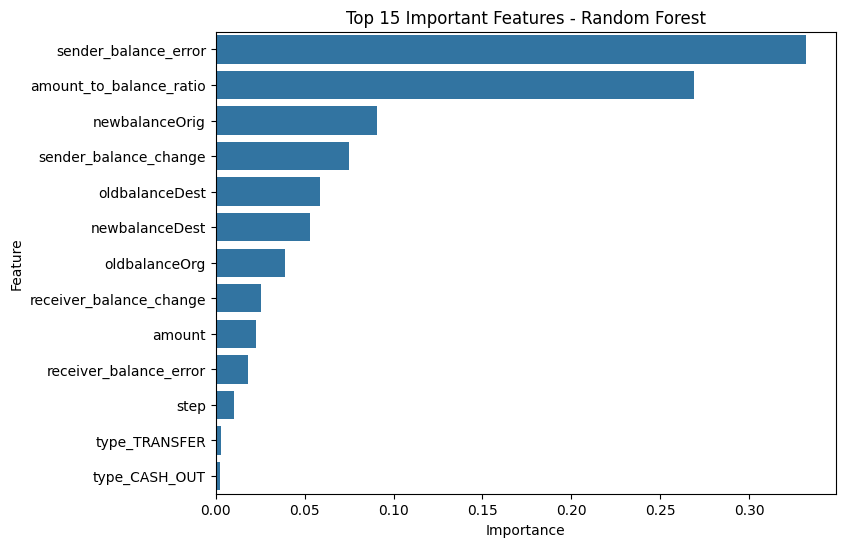

In [11]:
top_features = feature_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# 8. Results summary

This table shows how the models performed.


In [7]:
results_df = pd.DataFrame([log_reg_results, rf_results])
results_df_rounded = results_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

results_df_rounded


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9337,0.0144,0.7391,0.0282,0.9238,0.2337
1,Random Forest,0.9999,1.0000,0.9130,0.9545,0.9900,0.9358
